In [1]:
import pandas as pd, numpy as np, re, seaborn as sns, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from textblob import TextBlob

In [2]:
# 1. Load + Label Encode
df = pd.read_csv("/content/malicious_phish.csv")
df['label'] = LabelEncoder().fit_transform(df['type'])

In [3]:
# 2. Feature Engineering
df['url_length'] = df['url'].apply(len)
df['dot_count'] = df['url'].str.count('\.')
df['https'] = df['url'].apply(lambda x: int('https' in x.lower()))
df['sentiment'] = df['url'].apply(lambda x: TextBlob(x).sentiment.polarity)

In [4]:
df.describe()

,label,url_length,dot_count,https,sentiment
count,651191.000000,651191.000000,651191.000000,651191.000000,651191.000000
mean,0.681567,60.156831,2.195453,0.025221,0.000001
std,1.088137,44.753902,1.490732,0.156797,0.001726
min,0.000000,1.000000,0.000000,0.000000,-0.750000
25%,0.000000,32.000000,1.000000,0.000000,0.000000
50%,0.000000,47.000000,2.000000,0.000000,0.000000
75%,1.000000,77.000000,3.000000,0.000000,0.000000
max,3.000000,2175.000000,42.000000,1.000000,0.400000


<ipython-input-5-768bae5099c6>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='type', data=df, palette='viridis')
<ipython-input-5-768bae5099c6>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='type', y='dot_count', data=df, palette='coolwarm')
<ipython-input-5-768bae5099c6>:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='type', y='https', data=df, estimator=np.mean, palette='Set2')


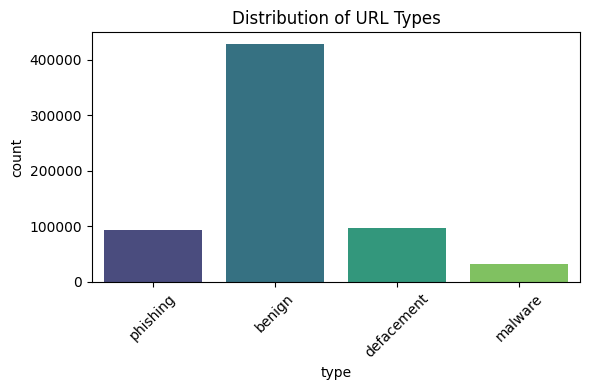

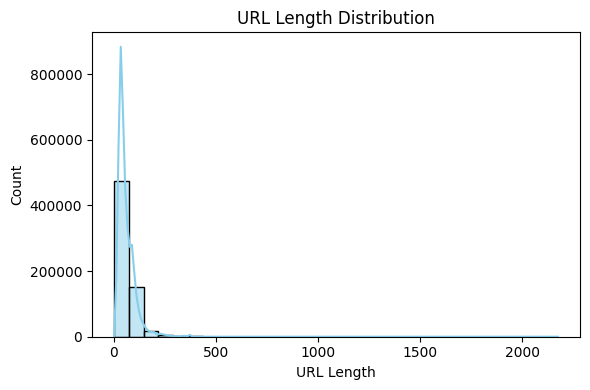

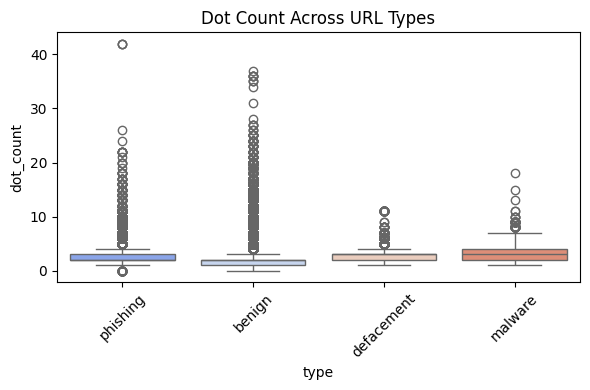

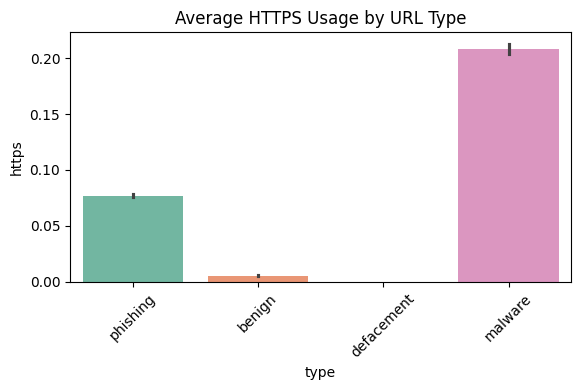

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# EDA 1: Class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='type', data=df, palette='viridis')
plt.title('Distribution of URL Types')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('eda_class_distribution.png')

# EDA 2: URL Length distribution
plt.figure(figsize=(6, 4))
sns.histplot(df['url_length'], kde=True, bins=30, color='skyblue')
plt.title('URL Length Distribution')
plt.xlabel('URL Length')
plt.tight_layout()
plt.savefig('eda_url_length.png')

# EDA 3: Dot count by class
plt.figure(figsize=(6, 4))
sns.boxplot(x='type', y='dot_count', data=df, palette='coolwarm')
plt.title('Dot Count Across URL Types')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('eda_dot_count.png')

# EDA 4: HTTPS presence by type
plt.figure(figsize=(6, 4))
sns.barplot(x='type', y='https', data=df, estimator=np.mean, palette='Set2')
plt.title('Average HTTPS Usage by URL Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('eda_https.png')


In [6]:
# Feature list for ML models
features = ['url_length', 'dot_count', 'https', 'sentiment']
X = df[features]
y = df['label']

# Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y)

# SMOTE to handle imbalance
from imblearn.over_sampling import SMOTE
X_train_res, y_train_res = SMOTE().fit_resample(X_train, y_train)

# Train ML Models
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier().fit(X_train_res, y_train_res)


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Optional: Scale data (helps logistic regression convergence)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression model
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train_res)

# Predict
y_pred_lr = lr_model.predict(X_test_scaled)

In [8]:
from sklearn.metrics import classification_report

# If you already predicted with both
y_pred_rf = rf_model.predict(X_test)
# (Assuming you’ve scaled and predicted with LR)
# y_pred_lr = lr_model.predict(X_test_scaled)

print("🔍 Random Forest:\n", classification_report(y_test, y_pred_rf))
print("🔍 Logistic Regression:\n", classification_report(y_test, y_pred_lr))

🔍 Random Forest:
               precision    recall  f1-score   support

           0       0.88      0.58      0.70    107026
           1       0.45      0.69      0.55     24114
           2       0.35      0.76      0.48      8130
           3       0.36      0.57      0.44     23528

    accuracy                           0.60    162798
   macro avg       0.51      0.65      0.54    162798
weighted avg       0.72      0.60      0.63    162798

🔍 Logistic Regression:
               precision    recall  f1-score   support

           0       0.84      0.61      0.71    107026
           1       0.43      0.60      0.50     24114
           2       0.24      0.29      0.26      8130
           3       0.29      0.51      0.37     23528

    accuracy                           0.58    162798
   macro avg       0.45      0.50      0.46    162798
weighted avg       0.67      0.58      0.61    162798



In [9]:
from xgboost import XGBClassifier

# Train XGBoost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
xgb_model.fit(X_train_res, y_train_res)

# Predict
y_pred_xgb = xgb_model.predict(X_test)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:27:12] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [10]:
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# Train LinearSVC (faster than kernel SVM)
svm_model = LinearSVC(max_iter=1000)
svm_model.fit(X_train_scaled, y_train_res)

# Predict
y_pred_svm = svm_model.predict(X_test_scaled)

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
model_preds = {
    'Random Forest': rf_model.predict(X_test),
    'Logistic Regression': lr_model.predict(X_test_scaled),  # Assuming scaled for LR
    'XGBoost': xgb_model.predict(X_test),
    'SVM': svm_model.predict(X_test_scaled)  # Assuming scaled for SVM
}

results = []
for name, preds in model_preds.items():
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds, average='weighted'),
        'Recall': recall_score(y_test, preds, average='weighted'),
        'F1 Score': f1_score(y_test, preds, average='weighted')
    })

# Create and display DataFrame
results_df = pd.DataFrame(results).sort_values(by='F1 Score', ascending=False)
print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score
2              XGBoost  0.610523   0.715111  0.610523  0.633511
0        Random Forest  0.603417   0.715713  0.603417  0.627556
3                  SVM  0.594043   0.668847  0.594043  0.616141
1  Logistic Regression  0.578908   0.671103  0.578908  0.606138


In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# 1. Use a smaller sample
df_sample = df.sample(n=10000, random_state=42)
tokenizer = Tokenizer(char_level=True, oov_token='<OOV>')
tokenizer.fit_on_texts(df_sample['url'])
X_seq = pad_sequences(tokenizer.texts_to_sequences(df_sample['url']), maxlen=75)
y_seq = df_sample['label']

# 2. Train-test split
X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(X_seq, y_seq, stratify=y_seq)

# 3. Small & fast LSTM
model = Sequential([
    Embedding(input_dim=len(tokenizer.word_index)+1, output_dim=16, input_length=75),
    LSTM(32),
    Dense(len(y_seq.unique()), activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train_dl, y_train_dl, epochs=2, batch_size=64, verbose=1)  # Only 2 epochs!

# 4. Evaluation
y_pred_dl = model.predict(X_test_dl)
y_pred_classes = y_pred_dl.argmax(axis=1)
print("Fast LSTM:\n", classification_report(y_test_dl, y_pred_classes))


Epoch 1/2


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


118/118 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.6421 - loss: 1.1215
Epoch 2/2
118/118 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.7018 - loss: 0.8203
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
Fast LSTM:
               precision    recall  f1-score   support

           0       0.83      0.88      0.85      1656
           1       0.45      0.92      0.60       359
           2       1.00      0.01      0.02       129
           3       0.00      0.00      0.00       356

    accuracy                           0.72      2500
   macro avg       0.57      0.45      0.37      2500
weighted avg       0.67      0.72      0.65      2500



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [16]:
history = model.fit(
    X_train_dl, y_train_dl,
    epochs=2,
    batch_size=64,
    validation_split=0.2,  # <-- Needed for val_accuracy
    verbose=1
)




Epoch 1/2
94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - accuracy: 0.7650 - loss: 0.5935 - val_accuracy: 0.7960 - val_loss: 0.5632
Epoch 2/2
94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.7828 - loss: 0.5384 - val_accuracy: 0.7840 - val_loss: 0.6207


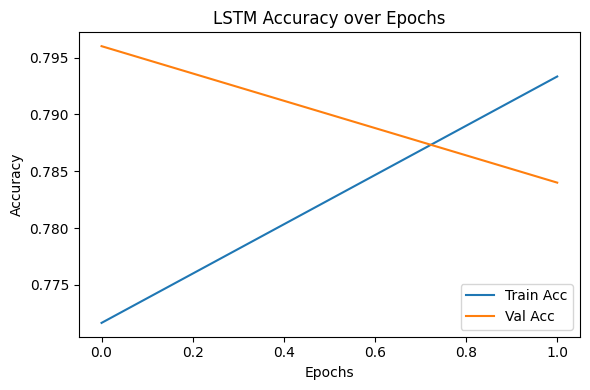

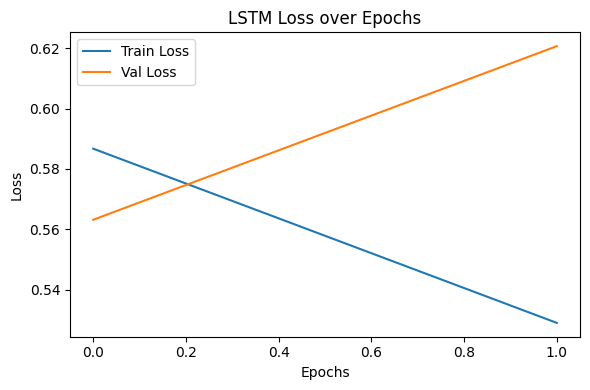

In [17]:
# Plot training history
history_dict = history.history

# Accuracy Plot
plt.figure(figsize=(6, 4))
plt.plot(history_dict['accuracy'], label='Train Acc')
plt.plot(history_dict['val_accuracy'], label='Val Acc')
plt.title("LSTM Accuracy over Epochs")
plt.xlabel("Epochs"); plt.ylabel("Accuracy"); plt.legend()
plt.tight_layout(); plt.savefig("lstm_accuracy.png")

# Loss Plot
plt.figure(figsize=(6, 4))
plt.plot(history_dict['loss'], label='Train Loss')
plt.plot(history_dict['val_loss'], label='Val Loss')
plt.title("LSTM Loss over Epochs")
plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.legend()
plt.tight_layout(); plt.savefig("lstm_loss.png")


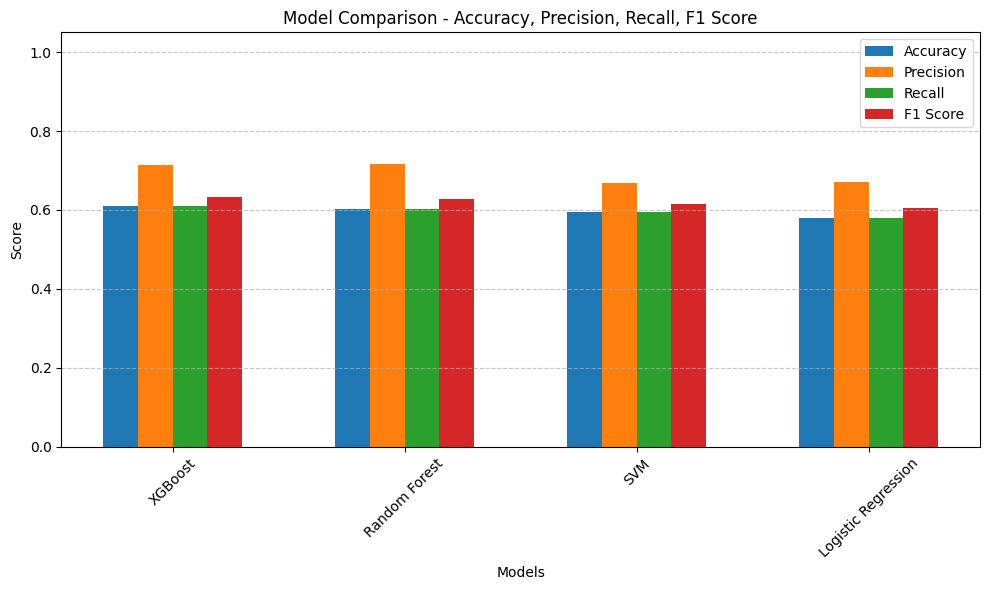

In [19]:
import matplotlib.pyplot as plt

# Ensure `results_df` contains all 5 models with correct metrics
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
model_names = results_df['Model'].tolist()

# Transpose the DataFrame to plot metrics as grouped bars
plot_df = results_df.set_index('Model')[metrics_to_plot].T

# Plot
plt.figure(figsize=(10, 6))
bar_width = 0.15
x = range(len(plot_df.columns))

# Plot each metric
for i, metric in enumerate(plot_df.index):
    plt.bar([p + bar_width*i for p in x], plot_df.loc[metric], width=bar_width, label=metric)

# Formatting
plt.xlabel("Models")
plt.ylabel("Score")
plt.title("Model Comparison - Accuracy, Precision, Recall, F1 Score")
plt.xticks([p + 1.5 * bar_width for p in x], plot_df.columns, rotation=45)
plt.ylim([0, 1.05])
plt.legend()
plt.tight_layout()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.savefig("model_comparison_bar_chart.png")
plt.show()


In [21]:
def extract_url_features(url):
    from textblob import TextBlob
    return {
        'url_length': len(url),
        'dot_count': url.count('.'),
        'https': int('https' in url.lower()),
        'sentiment': TextBlob(url).sentiment.polarity
    }


In [22]:
def predict_url_rf(url, model, label_encoder):
    import pandas as pd

    # Extract features and convert to DataFrame
    features = extract_url_features(url)
    input_df = pd.DataFrame([features])

    # Predict class
    prediction = model.predict(input_df)[0]
    pred_label = label_encoder.inverse_transform([prediction])[0]

    # Predict probability (optional)
    prob = model.predict_proba(input_df)[0].max()

    return f"🔍 URL: {url}\n📌 Prediction: {pred_label}\n✅ Confidence: {round(prob*100, 2)}%"


In [23]:
from sklearn.preprocessing import LabelEncoder

# Recreate and fit label encoder using original target column
le = LabelEncoder()
df['label'] = le.fit_transform(df['type'])  # use the original 'type' column (e.g., phishing, benign, etc.)


sample_url = "https://secure-login.verify-payment.com/update"
print(predict_url_rf(sample_url, rf_model, le))


🔍 URL: https://secure-login.verify-payment.com/update
📌 Prediction: phishing
✅ Confidence: 51.46%
